# Detekcja ataków sieciowych na zbiorze KDD Cup 1999
## Projekt zaliczeniowy AED
Celem projektu jest przygotowanie modelu ML służącego do wykrwyania ataków w ruchu sieciowym. 

Opiera się na zbiorze danych KDD Cup 1999, który zawiera opisy połączeń sieciowych oznaczonych jako połączenia normalne lub jako konkretne typu ataków.

## 1. Założenia projektowe

Projekt ma za zadanie klasyfikację połączeń sieciowych, gdzie każdy rekord w zbiorze opisuje jedno połączenie za pomocą cech numerycznych i kategorycznych.
Etykieta kolumny 42 wskazuje, czy połączenie było normalne, bądź stanowiło atak na sieć.

W projekcie przyjęto podejście klasyfikacji binarnej, gdzie:
- `normal` to polączenie normalne,
- `attack` jest atakiem na sieć.

Wszystkie konkretne typy ataków zostaną sprowadzone do wspólnej klasy `attack`.

### Struktura projektu

Projekt został zorganizowany w następujący sposób:

```text
AED_intrusion_detection/
├── data/
│   ├── raw/
│   └── processed/
├── notebooks/
│   └── kdd99_intrusion_detection.ipynb
├── reports/
├── src/
├── README.md
└── requirements.txt

## 2. Źródło danych

W projekcie wykorzystano zbiór KDD Cup 1999. Oryginalne wytyczne wskazują trzy pliki:

- `kddcup.data_10_percent.gz` - zbiór treningowy,
- `kddcup.testdata.unlabeled_10_percent.gz` -  zbiór testowy bez etykiet,
- `corrected.gz` — poprawione etykiety/dane testowe z etykietami.

Ze względu na ograniczenia dostępu do oryginalnego serwera KDD/UCI dane zostały pobrane z publicznego mirroru Kaggle, zachowano jednak strukturę danych zgodną z wytycznymi projektu. https://www.kaggle.com/datasets/galaxyh/kdd-cup-1999-data 


W projekcie używane są następujące pliki:

- `kddcup.data_10_percent`,
- `kddcup.testdata.unlabeled_10_percent`,
- `corrected`.

## 3. Wczytanie i weryfikacja danych

Na tym etapie sprawdzono, czy wszystkie wymagane pliki znajdują się w katalogu projektu oraz czy mają poprawny rozmiar.

Kontrola rozmiaru plików była istotna, ponieważ wcześniejsza próba pobrania danych z oryginalnego serwera `ics.uci.edu` zakończyła się uzyskaniem bardzo małych plików, które zawierały jedynie odnośniki, a nie właściwe dane.

Po poprawnym pobraniu pliki miały rozmiary rzędu kilkudziesięciu megabajtów, co potwierdziło, że zawierają rzeczywisty zbiór danych.

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

DATA_DIR = Path("../data/raw")

train_path = DATA_DIR / "kddcup.data_10_percent"
test_path = DATA_DIR / "kddcup.testdata.unlabeled_10_percent"
corrected_path = DATA_DIR / "corrected"

#sprawdzenie zestawów danych pod kątem odpowiedniego routingu i ilości danych
print("Train exists:", train_path.exists())
print("Test exists:", test_path.exists())
print("Corrected exists:", corrected_path.exists())

print("Train size MB:", round(train_path.stat().st_size / 1024 / 1024, 2))
print("Test size MB:", round(test_path.stat().st_size / 1024 / 1024, 2))
print("Corrected size MB:", round(corrected_path.stat().st_size / 1024 / 1024, 2))

Train exists: True
Test exists: True
Corrected exists: True
Train size MB: 71.42
Test size MB: 42.69
Corrected size MB: 45.06


## 4. Przygotowanie danych
Model opiera się na detekcji intruzji systemu, a nie klasyfikacji poszczególnych typów ataku. Na potrzeby projektu stworzono etykietę binarną normal/attack.

W tym etapie przygotowałem dane do użycia w modelach ML

Najważniejsze działania:

- nadanie nazw kolumnom,
- wyodrębnienie etykiet ze zbioru treningowego,
- wyodrębnienie etykiet testowych z pliku `corrected`,
- przekształcenie etykiet do postaci binarnej `normal` / `attack`,
- oddzielenie cech od zmiennej decyzyjnej,
- zakodowanie cech kategorycznych,
- wyrównanie kolumn między zbiorem treningowym i testowym.

Plik `corrected` został wykorzystany do jawnego wyodrębnienia etykiet testowych. Etykiety zostały pobrane z ostatniej kolumny i przekształcone do tablicy NumPy, aby mogły zostać użyte podczas ewaluacji modelu.

Przykład:

```text
normal.  → normal
neptune. → attack
smurf.   → attack
back.    → attack

### Nazwy kolumn
Pliki KDD Cup 1999 nie zawierają nagłówków kolumn. Pierwszy wiersz każdego pliku zawiera już obserwację, dlatego podczas wczytywania danych zastosowano `header=None`.

Nazwy 41 cech zostały odtworzone na podstawie dokumentacji zbioru KDD Cup 1999, w szczególności pliku `kddcup.names`. Do listy cech dodano kolumnę `label`, ponieważ zbiory `kddcup.data_10_percent` oraz `corrected` zawierają etykietę klasy w ostatniej kolumnie.

In [2]:
# dodanie nazw kolumn na bazie kdcup.names

columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
]

train_columns = columns + ["label"]
test_columns = columns
corrected_columns = columns + ["label"]

### Wczytanie zbiorów danych

In [3]:
# wczytanie zbiorów do pandas DataFrame 

train_df = pd.read_csv(train_path, header=None, names=train_columns)
test_df = pd.read_csv(test_path, header=None, names=test_columns)
corrected_df = pd.read_csv(corrected_path, header=None, names=corrected_columns)

print("Train shape:", train_df.shape)
print("Test unlabeled shape:", test_df.shape)
print("Corrected shape:", corrected_df.shape)

# pierwsze 5 wyników dla każdego zbioru
display(train_df.head())
display(test_df.head())
display(corrected_df.head())

Train shape: (494021, 42)
Test unlabeled shape: (311029, 41)
Corrected shape: (311029, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,udp,private,SF,105,146,0,0,0,0,...,255,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0
1,0,udp,private,SF,105,146,0,0,0,0,...,255,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0
2,0,udp,private,SF,105,146,0,0,0,0,...,255,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0
3,0,udp,private,SF,105,146,0,0,0,0,...,255,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0
4,0,udp,private,SF,105,146,0,0,0,0,...,255,254,1.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
1,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
2,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
3,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,snmpgetattack.
4,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,snmpgetattack.


### Wyodrębnienie etykiet testowych

Plik `corrected` zawiera pełne dane testowe razem z etykietą klasy w ostatniej kolumnie. Etykiety testowe zostały pobrane z kolumny `label`, a następnie przekonwertowane do tablicy NumPy.

In [4]:
test_labels = corrected_df["label"]

print("Typ danych przed konwersją:", type(test_labels))
print("Liczba etykiet testowych:", len(test_labels))

display(test_labels.head())

Typ danych przed konwersją: <class 'pandas.Series'>
Liczba etykiet testowych: 311029


0           normal.
1           normal.
2           normal.
3    snmpgetattack.
4    snmpgetattack.
Name: label, dtype: str

In [5]:
test_labels_array = test_labels.to_numpy()

print("Typ danych po konwersji:", type(test_labels_array))
print("Array shape:", test_labels_array.shape)
print("Pierwsze 10 etykiet:")
print(test_labels_array[:10])

Typ danych po konwersji: <class 'numpy.ndarray'>
Array shape: (311029,)
Pierwsze 10 etykiet:
['normal.' 'normal.' 'normal.' 'snmpgetattack.' 'snmpgetattack.'
 'snmpgetattack.' 'normal.' 'normal.' 'snmpgetattack.' 'normal.']


In [6]:
# podsumowanie ciągu danych dla 20 najczęstszych rodzajów rodzajów ataku
label_counts = pd.Series(test_labels_array).value_counts()

print("Liczba unikalnych etykiet testowych:", label_counts.shape[0])
display(label_counts.head(20))

Liczba unikalnych etykiet testowych: 38


smurf.              164091
normal.              60593
neptune.             58001
snmpgetattack.        7741
mailbomb.             5000
guess_passwd.         4367
snmpguess.            2406
satan.                1633
warezmaster.          1602
back.                 1098
mscan.                1053
apache2.               794
processtable.          759
saint.                 736
portsweep.             354
ipsweep.               306
httptunnel.            158
pod.                    87
nmap.                   84
buffer_overflow.        22
Name: count, dtype: int64

### Zmiana etykiet do postaci binarnej

Ponieważ etykiety mają klasę `normal` oraz wiele szczegółowych typów ataków, wszystkie etykiety różniące się od normal zostały zamienione na klasę `attack`.

In [7]:
y_test = np.where(test_labels_array == "normal.", "normal", "attack")

print("Typ danych dla etykiet testowych:", type(y_test))
print("\nShape etykiet testowych:", y_test.shape)
print("\nPierwsze 10 etykiet binarnych:")
print(y_test[:10])

test_binary_label_counts = pd.Series(y_test).value_counts()
display(test_binary_label_counts)

Typ danych dla etykiet testowych: <class 'numpy.ndarray'>

Shape etykiet testowych: (311029,)

Pierwsze 10 etykiet binarnych:
['normal' 'normal' 'normal' 'attack' 'attack' 'attack' 'normal' 'normal'
 'attack' 'normal']


attack    250436
normal     60593
Name: count, dtype: int64

In [8]:
train_labels = train_df["label"]

print("Oryginalne etykiety treningowe:")
display(train_labels.value_counts().head(20))

Oryginalne etykiety treningowe:


label
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
Name: count, dtype: int64

In [9]:
# dla pewności dodaję "normal"
y_train = np.where(train_labels == "normal.", "normal", "attack")

print("Typ danych dla etykiet treningowych:", type(y_train))
print("\nShape etykiet treningowych:", y_train.shape)

train_binary_label_counts = pd.Series(y_train).value_counts()
display(train_binary_label_counts)

Typ danych dla etykiet treningowych: <class 'numpy.ndarray'>

Shape etykiet treningowych: (494021,)


attack    396743
normal     97278
Name: count, dtype: int64

### Oddzielenie cech od etykiet

Po przygotowaniu binarnych label'ów oddzielono cechy wejściowe od zmiennej decyzyjnyej.

Modele będą trenowane na `X_train` i `y_train`, a następnie oceniane na `X_test` i `y_test`.

In [10]:
X_train_raw = train_df.drop(columns=["label"])
X_test_raw = corrected_df.drop(columns=["label"])

print("X_train_raw shape:", X_train_raw.shape)
print("y_train shape:", y_train.shape)

print("X_test_raw shape:", X_test_raw.shape)
print("y_test shape:", y_test.shape)

X_train_raw shape: (494021, 41)
y_train shape: (494021,)
X_test_raw shape: (311029, 41)
y_test shape: (311029,)


### Kodowanie cech kategorycznych

Zbiór zawiera cechy kategoryczne, które muszą zostać przekształcone do postaci numerycznej. W projekcie zastosowano one-hot encoding dla zmiennych:

- `protocol_type`,
- `service`,
- `flag`.

Po zakodowaniu cech kategorycznych wyrównano kolumny między zbiorem treningowym i testowym, ponieważ niektóre kategorie występowały tylko w jednym ze zbiorów.

In [11]:
categorical_columns = ["protocol_type", "service", "flag"]

print("Liczba unikalnych wartości w treningowych cechach kategorycznych :")
for col in categorical_columns:
    print(col, X_train_raw[col].nunique())

print("\nLiczba unikalnych wartości w testowych cechach kategorycznych:")
for col in categorical_columns:
    print(col, X_test_raw[col].nunique())

Liczba unikalnych wartości w treningowych cechach kategorycznych :
protocol_type 3
service 66
flag 11

Liczba unikalnych wartości w testowych cechach kategorycznych:
protocol_type 3
service 65
flag 11


In [12]:
# get_dummies ma na celu przekonwertowanie zmiennych kategorycznych do wymiaru unikalnych rekordów
X_train_encoded = pd.get_dummies(
    X_train_raw,
    columns=categorical_columns,
    drop_first=False
)

X_test_encoded = pd.get_dummies(
    X_test_raw,
    columns=categorical_columns,
    drop_first=False
)

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

X_train_encoded shape: (494021, 118)
X_test_encoded shape: (311029, 117)


In [13]:
# left join na danych w celu ujednolicenia wyników
X_train, X_test = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

print("X_train po align:", X_train.shape)
print("X_test po align:", X_test.shape)
print("Czy kolumny się zgadzają? ", list(X_train.columns) == list(X_test.columns))

X_train po align: (494021, 118)
X_test po align: (311029, 118)
Czy kolumny się zgadzają?  True


In [14]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

print("Końcowa forma X_train:", X_train.shape)
print("Końcowa forma X_test:", X_test.shape)
print("Końcowa forma y_train:", y_train.shape)
print("Końcowa forma y_test:", y_test.shape)

Końcowa forma X_train: (494021, 118)
Końcowa forma X_test: (311029, 118)
Końcowa forma y_train: (494021,)
Końcowa forma y_test: (311029,)


### Podsumowanie transfomracji danych

In [15]:
print("Rozmiary danych po przygotowaniu:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nLiczba cech po encodingu one-hot:", X_train.shape[1])
print("Czy kolumny train/test są identyczne:", list(X_train.columns) == list(X_test.columns))

Rozmiary danych po przygotowaniu:
X_train: (494021, 118)
X_test: (311029, 118)
y_train: (494021,)
y_test: (311029,)

Liczba cech po encodingu one-hot: 118
Czy kolumny train/test są identyczne: True


## 5. EDA
Ta sekcja zawiera analizę eksploracyjną danych.

Analizowane są rozmiary zbiorów, typy zmiennych, rozkład etykiet oraz udział połączeń normalnych i ataków.

### Rozkład klas binarnych



In [16]:
train_binary_counts = pd.Series(y_train).value_counts()
test_binary_counts = pd.Series(y_test).value_counts()

print("Rozkład klas w zbiorze treningowym:")
display(train_binary_counts)

print("Rozkład klas w zbiorze testowym:")
display(test_binary_counts)

train_binary_percent = pd.Series(y_train).value_counts(normalize=True) * 100
test_binary_percent = pd.Series(y_test).value_counts(normalize=True) * 100

print("Procentowy rozkład klas w zbiorze treningowym:")
display(train_binary_percent.round(2))

print("Procentowy rozkład klas w zbiorze testowym:")
display(test_binary_percent.round(2))

Rozkład klas w zbiorze treningowym:


attack    396743
normal     97278
Name: count, dtype: int64

Rozkład klas w zbiorze testowym:


attack    250436
normal     60593
Name: count, dtype: int64

Procentowy rozkład klas w zbiorze treningowym:


attack    80.31
normal    19.69
Name: proportion, dtype: float64

Procentowy rozkład klas w zbiorze testowym:


attack    80.52
normal    19.48
Name: proportion, dtype: float64

### Wykres rozkładu klas

Pozwala na szybką ocenę balansu badanego problemu. W przypadku wykrywania ataków sieciowych, niezbalansowane klasy mogą istotnie wpłynąć na wynik i interpretację rezultatów modelu.

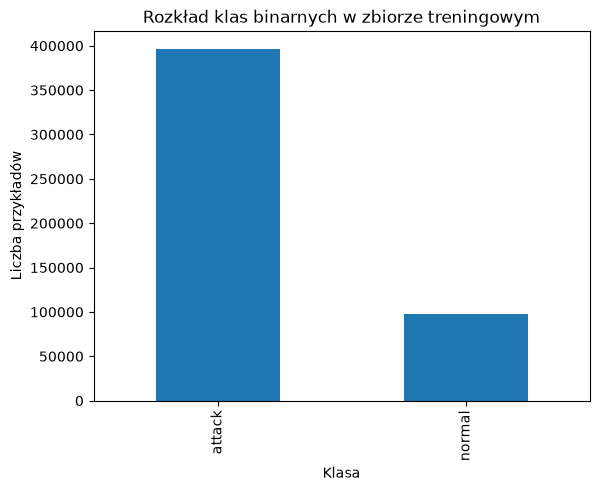

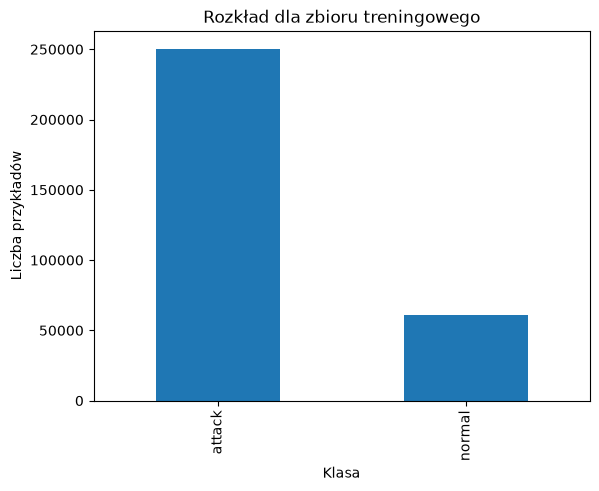

In [17]:
import matplotlib.pyplot as plt

train_binary_counts.plot(kind='bar', )
plt.title("Rozkład klas binarnych w zbiorze treningowym")
plt.xlabel("Klasa")
plt.ylabel("Liczba przykładów")
plt.show()

test_binary_counts.plot(kind='bar', )
plt.title("Rozkład dla zbioru treningowego")
plt.xlabel("Klasa")
plt.ylabel("Liczba przykładów")
plt.show()


### Typy ataków

Oryginalny dataset posiada wiele różnych typów ataków. Przy analizie warto mieć świadomość najczęstszych występujących, aby lepiej zrozumieć badany problem.

In [18]:
print("Najczęściej występujące ataki sieciowe w zbiorze treningowym")
display(train_df["label"].value_counts().head(20))

print("Najczęściej występujące ataki sieciowe w zbiorze testowym")
display(corrected_df["label"].value_counts().head(20))

Najczęściej występujące ataki sieciowe w zbiorze treningowym


label
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
Name: count, dtype: int64

Najczęściej występujące ataki sieciowe w zbiorze testowym


label
smurf.              164091
normal.              60593
neptune.             58001
snmpgetattack.        7741
mailbomb.             5000
guess_passwd.         4367
snmpguess.            2406
satan.                1633
warezmaster.          1602
back.                 1098
mscan.                1053
apache2.               794
processtable.          759
saint.                 736
portsweep.             354
ipsweep.               306
httptunnel.            158
pod.                    87
nmap.                   84
buffer_overflow.        22
Name: count, dtype: int64

### Kontrola braków w danych

Sprawdzenie dokładności danych pod kątem braków przed treningiem modeli.

In [19]:
missingval_train = train_df.isna().sum().sum()
missingval_test = corrected_df.isna().sum().sum()

print("Brakujących wartości w train_df:", missingval_train)
print("Brakujących wartości w corrected_df:", missingval_test)

Brakujących wartości w train_df: 0
Brakujących wartości w corrected_df: 0


In [20]:
display(train_binary_counts)
display(test_binary_counts)
display(train_df["label"].value_counts().head(20))
display(corrected_df["label"].value_counts().head(20))

attack    396743
normal     97278
Name: count, dtype: int64

attack    250436
normal     60593
Name: count, dtype: int64

label
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
Name: count, dtype: int64

label
smurf.              164091
normal.              60593
neptune.             58001
snmpgetattack.        7741
mailbomb.             5000
guess_passwd.         4367
snmpguess.            2406
satan.                1633
warezmaster.          1602
back.                 1098
mscan.                1053
apache2.               794
processtable.          759
saint.                 736
portsweep.             354
ipsweep.               306
httptunnel.            158
pod.                    87
nmap.                   84
buffer_overflow.        22
Name: count, dtype: int64

### Podsumowanie EDA

EDA potwierdziła, że zbiory treningowe i testowe mają poprawną strukturę oraz posiadają tę samą liczbę cech.

Rozkład klas `normal/attack` wykazał proporcje w stosunku zbliżonym do `20:80`. Oznacza to, że większość rekordów jest zakwalifikowana jako atak na sieć. 
Dane treningowe posiadają prawie 400 000 rekordów ataków i prawie 100 000 połączeń bezpiecznych.

Dane testowe zawierają 250 436 rekordy ataków i 60 593 połączeń bezpiecznych.


W zestawach występują zarówne cechy numeryczne, jak i kategoryczne.
Cechy kategoryczne zostały wcześniej zakodowane metodą one-hot encoding, dzięki czemu dane mogą zostać przekazane do modeli klasyfikacyjnych.

Z analizy typów ataków wynika, że najczęściej występującymi atakami są `smur.` oraz `neptune.` Klasyfikacja binarna jest tu uzasadniona, ponieważ lepiej odpowiada głównemu celowi projektu.

## 6. Modelowanie i finetuning

Celem tego etapu jest:

- wytrenowanie modelu bazowego DT,
- porównanie kilku konfiguracji parametrów,
- wytrenowanie modelu ensemble Random Forest,
- przygotowanie wyników do końcowej ewaluacji.

Wszystkie modele rozwiązują problem klasyfikacji binarnej: `normal` / `attack`.

### Funkcja ewaluacyjna

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def evaluate_model(model_name, y_true, y_pred):

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_attack": precision_score(y_true, y_pred, pos_label="attack"),
        "recall_attack": recall_score(y_true, y_pred, pos_label="attack"),
        "f1_attack": f1_score(y_true, y_pred, pos_label="attack"),
    }

    return results

### Baseline: Decision Tree

Drzewo decyzyjne będzie użyte jako punkt odniesienia dla dalszych metod. 

Wybrałem je ze względu na stosunkową łatwość i szybkość przy procesowaniu danych z tabeli.

In [22]:
from sklearn.tree import DecisionTreeClassifier

dt_baseline = DecisionTreeClassifier(
    random_state = 67)

dt_baseline.fit(X_train, y_train)

y_pred_dt_baseline = dt_baseline.predict(X_test)

dt_baseline_result = evaluate_model(
    "Baseline DT",
    y_test,
    y_pred_dt_baseline
)

dt_baseline_result


{'model': 'Baseline DT',
 'accuracy': 0.9346749016972694,
 'precision_attack': 0.9985830170037959,
 'recall_attack': 0.920175214426041,
 'f1_attack': 0.9577770943126465}

In [23]:
# classification report

print("Report klasyfikatora dla bazowego Decision Tree")
print(classification_report(y_test, y_pred_dt_baseline))

# confusion matrix

cm_dt_baseline = confusion_matrix(
    y_test,
    y_pred_dt_baseline,
    labels=["normal", "attack"]
)

cm_dt_baseline

cm_dt_baseline_df = pd.DataFrame(
    cm_dt_baseline,
    index=["Actual normal", "Actual attack"],
    columns=["Predicted normal", "Predicted attack"]
)

display(cm_dt_baseline_df)

Report klasyfikatora dla bazowego Decision Tree
              precision    recall  f1-score   support

      attack       1.00      0.92      0.96    250436
      normal       0.75      0.99      0.86     60593

    accuracy                           0.93    311029
   macro avg       0.87      0.96      0.91    311029
weighted avg       0.95      0.93      0.94    311029



,Predicted normal,Predicted attack
Actual normal,60266,327
Actual attack,19991,230445


#### Tuning DT

In [24]:
# tabela z różnymi konfiguracjami pod tuning DT
dt_configs = [
    {
        "name": "DT max_depth=5",
        "params": {
            "max_depth": 5,
            "random_state": 67
        }
    },
    {
        "name": "DT max_depth=10",
        "params": {
            "max_depth": 10,
            "random_state": 67
        }
    },
    {
        "name": "DT max_depth=20",
        "params": {
            "max_depth": 20,
            "random_state": 67
        }
    },
    {
        "name": "DT max_depth=20, min_samples_split=10",
        "params": {
            "max_depth": 20,
            "min_samples_split": 10,
            "random_state": 67
        }
    }
]

In [25]:
model_results = []
model_results.append(dt_baseline_result)

for config in dt_configs:
    model = DecisionTreeClassifier(**config["params"])
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results = evaluate_model(
        config["name"],
        y_test,
        y_pred
    )

    model_results.append(results)

dt_results_df = pd.DataFrame(model_results)

# sortowanie po najlepszym f1-score
dt_results_df.sort_values(by="f1_attack", ascending=False)
dt_results_df

,model,accuracy,precision_attack,recall_attack,f1_attack
0,Baseline DT,0.934675,0.998583,0.920175,0.957777
1,DT max_depth=5,0.926415,0.998558,0.909925,0.952184
2,DT max_depth=10,0.928537,0.998528,0.912592,0.953628
3,DT max_depth=20,0.933434,0.998555,0.918658,0.956941
4,"DT max_depth=20, min_samples_split=10",0.934109,0.998543,0.919508,0.957397


#### Podsumowanie DT

Wyniki pokazują, że drzewo decyzyjne jest bardzo skuteczne w binarnej formie wykrywania ataków. Najlepszy wynik według miary F1 dla klasy `attack` uzyskał model bazowy.

``` text
model	        accuracy	precision_attack	recall_attack	    f1_attack
Baseline DT	0.934675	0.998583	        0.920175	    0.957777

Wszystkie konfiguracje osiągnęły bardzo wysoką wartość precision, co oznacza, że przewidywania ataku były zazwyczaj trafne. Niższa wartość recall wskazuje jednak, że część ataków została błędnie zaklasyfikowana jako False Negative.

Modele z ograniczoną głębokością (`max_depth=5` oraz `max_depth=10`) uzyskały nieco słabsze wyniki, co sugeruje, że zbyt płytkie drzewo nie jest wystarczająco elastyczne dla tego zbioru danych. Konfiguracja `max_depth=20` oraz `min_samples_split=10` osiągnęła wynik bardzo zbliżony do modelu bazowego, przy jednoczesnym większym ograniczeniu złożoności modelu.

### Random Forest ensemble

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    random_state=67,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

y_pred_rf_baseline = rf_baseline.predict(X_test)

rf_baseline_result = evaluate_model(
    "RF maxdepth=20, 50 drzew",
    y_test,
    y_pred_rf_baseline
)

rf_baseline_result

{'model': 'RF maxdepth=20, 50 drzew',
 'accuracy': 0.9265791935800198,
 'precision_attack': 0.9986766226709436,
 'recall_attack': 0.9100209235093996,
 'f1_attack': 0.9522898211599532}

In [27]:
model_results.append(rf_baseline_result)

results_df=pd.DataFrame(model_results)
results_df.sort_values(by="f1_attack", ascending=False)

,model,accuracy,precision_attack,recall_attack,f1_attack
0,Baseline DT,0.934675,0.998583,0.920175,0.957777
4,"DT max_depth=20, min_samples_split=10",0.934109,0.998543,0.919508,0.957397
3,DT max_depth=20,0.933434,0.998555,0.918658,0.956941
2,DT max_depth=10,0.928537,0.998528,0.912592,0.953628
5,"RF maxdepth=20, 50 drzew",0.926579,0.998677,0.910021,0.952290
1,DT max_depth=5,0.926415,0.998558,0.909925,0.952184


Random Forest ma bardzo wysoką precyzję dla `attack`, ale wyniki nie różnią się zbytnio od Decision Tree.
Problemem jest niższy `recall_attack`, który wykrywa mniej ataków niż najlepszy DT.

Podstawą dla tuningu będzie tu brak ograniczeń głębokości drzewa.

#### Tuning Random Forest

In [28]:
rf_configs = [
    {
        "name": "RF 50 drzew, bez max_depth",
        "params": {
            "n_estimators": 50,
            "max_depth": None,
            "random_state": 67,
            "n_jobs": -1
        }
    },
    {
        "name": "RF 100 drzew, bez max_depth",
        "params": {
            "n_estimators": 100,
            "max_depth": None,
            "random_state": 67,
            "n_jobs": -1
        }
    },
]

In [29]:
for config in rf_configs:
    model = RandomForestClassifier(**config["params"])
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results = evaluate_model(
        config["name"],
        y_test,
        y_pred
    )

    model_results.append(results)
results_df = pd.DataFrame(model_results)
results_df.sort_values(by="f1_attack", ascending=False)

,model,accuracy,precision_attack,recall_attack,f1_attack
0,Baseline DT,0.934675,0.998583,0.920175,0.957777
4,"DT max_depth=20, min_samples_split=10",0.934109,0.998543,0.919508,0.957397
3,DT max_depth=20,0.933434,0.998555,0.918658,0.956941
2,DT max_depth=10,0.928537,0.998528,0.912592,0.953628
7,"RF 100 drzew, bez max_depth",0.927975,0.998670,0.911762,0.953239
6,"RF 50 drzew, bez max_depth",0.926820,0.998681,0.910316,0.952454
5,"RF maxdepth=20, 50 drzew",0.926579,0.998677,0.910021,0.952290
1,DT max_depth=5,0.926415,0.998558,0.909925,0.952184


### Interpretacja i podsumowanie wyników modelowania

W ramach modelowania porównano kilka konfiguracji drzewa decyzyjnego oraz modelu Random Forest. Najlepszy wynik według miary F1 dla klasy `attack` uzyskało bazowe drzewo decyzyjne bez jawnego ograniczenia głębokości.

Wszystkie modele osiągnęły bardzo wysoką wartość precision dla klasy `attack`, co oznacza, że przypadki przewidziane jako ataki były zazwyczaj klasyfikowane poprawnie. Większe różnice pojawiły się w wartości recall dla klasy `attack`, czyli w zdolności modelu do wykrywania wszystkich rzeczywistych ataków.

Modele Random Forest nie poprawiły wyników względem najlepszego drzewa decyzyjnego w testowanych konfiguracjach. Najlepszy model Random Forest uzyskał niższą wartość recall i F1-score dla klasy `attack` niż bazowe drzewo decyzyjne. Może to oznaczać, że w tym zbiorze danych pojedyncze głębokie drzewo dobrze uchwyciło reguły rozróżniające połączenia normalne od ataków.

Każdy z modeli przeszedł proces tuningu za pomocą zmiany różnych wartości parametrów, tj. `max_depth`, `min_samples_split` oraz `n_estimators`.

## 7. Ewaluacja i wnioski

Końcowa ocena najlepszego modelu. Na podstawie wyników z etapu szóstego wybrano bazowe Decision Tree, które uzyskało najwyższą wartość F1-score dla klasy `attack`.

Ewaluacja obejmuje:

- raport klasyfikacji,
- macierz pomyłek,
- interpretację błędów false positive i false negative,
- końcowe wnioski dotyczące skuteczności modelu.

In [30]:
best_model = dt_baseline
best_model_name = "Baseline Decision Tree"

y_pred_best = best_model.predict(X_test)

best_model_results = evaluate_model(
    best_model_name,
    y_test,
    y_pred_best
)

best_model_results

{'model': 'Baseline Decision Tree',
 'accuracy': 0.9346749016972694,
 'precision_attack': 0.9985830170037959,
 'recall_attack': 0.920175214426041,
 'f1_attack': 0.9577770943126465}

### Raport klasyfikacji
Przedstawia finalne wartości najlepszego modelu: accuracy, precision, recall i F1-score

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

      attack       1.00      0.92      0.96    250436
      normal       0.75      0.99      0.86     60593

    accuracy                           0.93    311029
   macro avg       0.87      0.96      0.91    311029
weighted avg       0.95      0.93      0.94    311029



### Macierz pomyłek
W projekcie przyjęto następującą interpretację:

- true negative - połączenie normalne poprawnie rozpoznane jako normalne,
- false negative - połączenie normalne błędnie uznane za atak,
- false positive - atak błędnie uznany za połączenie normalne,
- true positive - atak poprawnie rozpoznany jako atak.

W kontekście bezpieczeństwa sieciowego szczególnie istotne jest false negative, które oznaczają ataki niewykryte przez model.

In [32]:
from sklearn.metrics import confusion_matrix

cm_best = confusion_matrix(
    y_test,
    y_pred_best,
    labels=["normal", "attack"]
)

cm_best_df = pd.DataFrame(
    cm_best,
    index=["Faktycznie normal", "Faktycznie attack"],
    columns=["Przewidywany normal", "Przewidywany attack"]
)

display(cm_best_df)

tn = cm_best[0, 0]  # actual normal, predicted normal
fp = cm_best[0, 1]  # actual normal, predicted attack
fn = cm_best[1, 0]  # actual attack, predicted normal
tp = cm_best[1, 1]  # actual attack, predicted attack

print("True negative / normal poprawnie:", tn)
print("False positive / normal uznane za attack:", fp)
print("False negative / attack uznany za normal:", fn)
print("True positive / attack poprawnie:", tp)

print("\nFalse positive rate:", round(fp / (fp + tn), 4))
print("False negative rate:", round(fn / (fn + tp), 4))

,Przewidywany normal,Przewidywany attack
Faktycznie normal,60266,327
Faktycznie attack,19991,230445


True negative / normal poprawnie: 60266
False positive / normal uznane za attack: 327
False negative / attack uznany za normal: 19991
True positive / attack poprawnie: 230445

False positive rate: 0.0054
False negative rate: 0.0798


Model poprawnie rozpoznał 230445 ataków oraz 60266 normalnych połączeń. Liczba fałszywych alarmów była bardzo niska: tylko 327 normalnych połączeń zostało błędnie zaklasyfikowanych jako atak. Większym problemem są przypadki false negative: 19991 ataków zostało błędnie uznanych za połączenia normalne.

False positive rate wyniósł 0.0054, co oznacza, że model bardzo rzadko oznaczał normalny ruch jako atak. False negative rate wyniósł 0.0798, więc około 8% ataków nie zostało wykrytych.

 W kontekście bezpieczeństwa sieciowego jest to najważniejsze ograniczenie modelu, ponieważ niewykryty atak stanowi większe ryzyko niż fałszywy alarm.

#### Wizualizacja macierzy omyłek

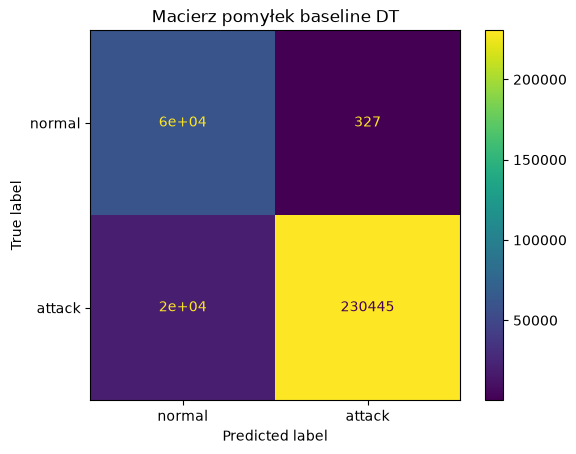

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=["normal", "attack"]
)

disp.plot()
plt.title("Macierz pomyłek baseline DT")
plt.show()



### Porównanie wszystkich modeli

Zestawienie wytrenowanych modeli i ich konfiguracji. Modele zostały posortowane wg metryki F1-score, ponieważ łączy recall i precision dla klasy `attack` i dobrze opisuje skuteczność wykrywania ataków.

In [34]:
final_results_df = results_df.sort_values(by="f1_attack", ascending=False)
display(final_results_df)

,model,accuracy,precision_attack,recall_attack,f1_attack
0,Baseline DT,0.934675,0.998583,0.920175,0.957777
4,"DT max_depth=20, min_samples_split=10",0.934109,0.998543,0.919508,0.957397
3,DT max_depth=20,0.933434,0.998555,0.918658,0.956941
2,DT max_depth=10,0.928537,0.998528,0.912592,0.953628
7,"RF 100 drzew, bez max_depth",0.927975,0.998670,0.911762,0.953239
6,"RF 50 drzew, bez max_depth",0.926820,0.998681,0.910316,0.952454
5,"RF maxdepth=20, 50 drzew",0.926579,0.998677,0.910021,0.952290
1,DT max_depth=5,0.926415,0.998558,0.909925,0.952184


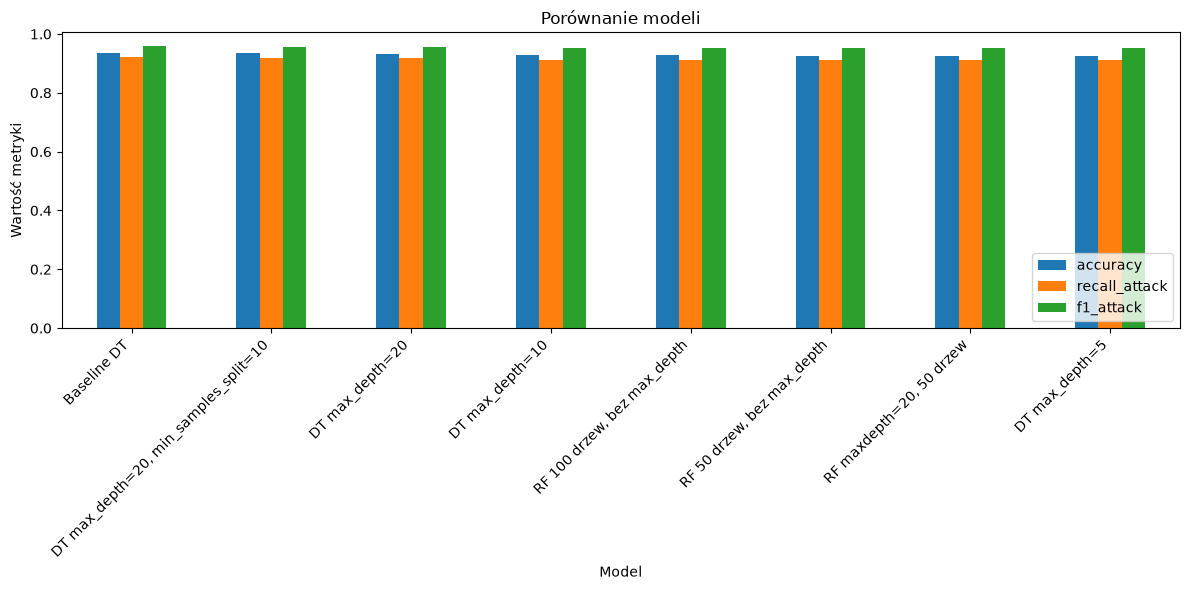

In [38]:
final_results_df.plot(
    x="model",
    y=["accuracy", "recall_attack", "f1_attack"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Porównanie modeli")
plt.xlabel("Model")
plt.ylabel("Wartość metryki")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Wnioski końcowe

Celem projektu było zbudowanie modelu wykrywania ataków sieciowych na zbiorze KDD Cup 1999. Problem został potraktowany jako klasyfikacja binarna, w której połączenia oznaczono jako `normal` lub `attack`.

Ze względu na brak dostępu do zbioru danych dostarczonego w wymaganiach zadania, pobrałem dataset dostępny na Kaggle.

Dane zostały wczytane, sprawdzone pod kątem zgodności i rozmiaru oraz przygotowane do modelowania. 
Oryginalne etykiety zawierające wiele typów ataków zostały sprowadzone do jednej klasy `attack`. 
Cechy kategoryczne zostały zakodowane metodą one-hot encoding, a kolumny między zbiorem treningowym i testowym zostały wyrównane lewostronnie.

Porównano kilka konfiguracji drzewa decyzyjnego oraz modelu Random Forest. `Najlepszy wynik uzyskał baseline DT.` Model ten osiągnął najwyższą wartość F1-score oraz najwyższy recall dla klasy `attack` spośród wszystkich, testowanych konfiguracji.


Wysoka wartość precision dla klasy `attack` oznacza, że model rzadko oznaczał normalne połączenia jako ataki. Recall dla klasy `attack` pokazuje jednak, że pewna część ataków nadal została błędnie zaklasyfikowana jako połączenia normalne. W praktycznym systemie bezpieczeństwa takie przypadki byłyby szczególnie istotne, ponieważ oznaczają niewykryte intruzje.

Model Random Forest, mimo że jest metodą grupowania, nie poprawił wyników względem najlepszego drzewa decyzyjnego w testowanych konfiguracjach. 

Może to oznaczać, że w tym zbiorze danych pojedyncze głębokie drzewo dobrze uchwyciło reguły odróżniające ruch normalny od ataków.

Projekt spełnia założenia dokumentacji: zastosowano algorytmy klasyfikacyjne, przeprowadzono strojenie parametrów oraz oceniono model na danych testowych z użyciem odpowiednich metryk klasyfikacyjnych.